# Classification after-class exercise — Tutor solution
### Worked solution and marking guidance

This notebook mirrors `classification_students.ipynb`. Model comparison and threshold selection use validation data; the final test set is opened only after every decision is fixed. AI4I is a published synthetic, physics-based benchmark, and the exercise costs are illustrative rather than site-specific.

## 0. Setup 


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay,
)

project_root = Path.cwd()
if project_root.name == "solutions":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from exercise_data import load_ai4i

def metric_row(y_true, prediction, probability):
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
    }

plt.rcParams["figure.figsize"] = (8, 4)
print("Setup complete")

Setup complete


In [2]:
# exercise_data.py is imported from the repository root by the setup cell.
# Set this to False if you want the exact seeded fallback results.
PREFER_PUBLISHED_DATA = True
pm = load_ai4i(prefer_published=PREFER_PUBLISHED_DATA)
print("Source:", pm.attrs["source"])
pm.head()

Loaded PUBLISHED AI4I dataset (synthetic): 10000 rows × 12 columns
Source: PUBLISHED AI4I dataset (synthetic)


,type,air_temp,proc_temp,speed,torque,tool_wear,TWF,HDF,PWF,OSF,RNF,fail
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1. The accuracy trap

In [3]:
FAILURE_MODES = ["TWF", "HDF", "PWF", "OSF", "RNF"]

failure_rate = pm["fail"].mean()
mode_counts = pm[FAILURE_MODES].sum()

always_healthy = np.zeros(len(pm), dtype=int)
baseline_accuracy = accuracy_score(pm["fail"], always_healthy)
baseline_recall = recall_score(pm["fail"], always_healthy, zero_division=0)

print(f"Failure rate: {failure_rate:.3%}")
print("Failures by mode:")
display(mode_counts.to_frame("count"))
print(f"Always-healthy accuracy: {baseline_accuracy:.3f}")
print(f"Always-healthy recall:   {baseline_recall:.3f}")

assert 0 < failure_rate < 0.15
assert baseline_recall == 0

Failure rate: 3.390%
Failures by mode:


,count
TWF,46
HDF,115
PWF,95
OSF,98
RNF,19


Always-healthy accuracy: 0.966
Always-healthy recall:   0.000


### Model answer 1

The always-healthy policy scores about 93–97% accuracy because healthy observations dominate, but recall is exactly zero: it catches no failures. Every accuracy claim should be accompanied by class prevalence and a confusion matrix or class-specific metrics such as precision and recall.

## 2. Reserve validation and final-test data 

In [4]:
RAW_FEATURES = ["air_temp", "proc_temp", "speed", "torque", "tool_wear"]
X = pm[RAW_FEATURES].copy()
X = pd.concat(
    [X, pd.get_dummies(pm["type"], prefix="type", drop_first=True, dtype=int)],
    axis=1,
)
y = pm["fail"].copy()

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.40, random_state=0, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_holdout, y_holdout, test_size=0.50, random_state=1, stratify=y_holdout
)

print("rows:", len(X_train), "train |", len(X_val), "validation |", len(X_test), "test")
print("failure rates:", y_train.mean().round(3), y_val.mean().round(3), y_test.mean().round(3))

assert len(X_train) + len(X_val) + len(X_test) == len(pm)
assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)

rows: 6000 train | 2000 validation | 2000 test
failure rates: 0.034 0.034 0.034


## 3. First classifier and confusion matrix

accuracy     0.971
precision    0.750
recall       0.221
f1           0.341
roc_auc      0.879
pr_auc       0.422
Name: plain logistic, dtype: float64

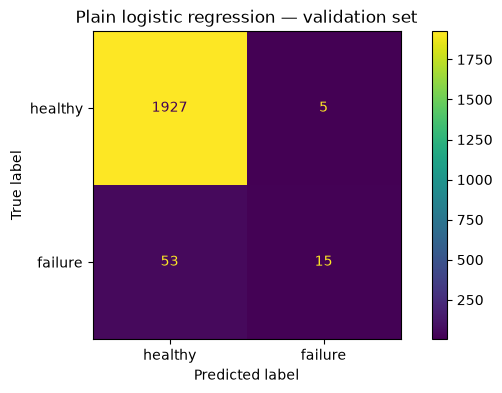

In [5]:
plain_logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
plain_logit.fit(X_train, y_train)
val_prediction = plain_logit.predict(X_val)
val_probability = plain_logit.predict_proba(X_val)[:, 1]
plain_metrics = metric_row(y_val, val_prediction, val_probability)

display(pd.Series(plain_metrics, name="plain logistic").round(3))
ConfusionMatrixDisplay.from_predictions(y_val, val_prediction, display_labels=["healthy", "failure"])
plt.title("Plain logistic regression — validation set")
plt.show()

assert set(plain_metrics) == {"accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"}

### Model answer 2

Plain logistic regression usually catches very few failures at threshold 0.5. The loss is dominated by healthy observations and several physical rules involve products or differences that a raw linear boundary cannot represent. A false positive triggers an unnecessary inspection; a false negative allows an impending failure to pass without an alarm.

## 4. Compare model families

In [6]:
models = {
    "balanced logistic": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")
    ),
    "decision tree": DecisionTreeClassifier(max_depth=6, random_state=0),
    "random forest": RandomForestClassifier(n_estimators=200, random_state=0),
}

validation_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_val)
    probability = model.predict_proba(X_val)[:, 1]
    validation_rows.append({"model": name, **metric_row(y_val, prediction, probability)})

model_results = pd.DataFrame(validation_rows).set_index("model")
display(model_results.round(3))

assert len(model_results) == 3
assert np.isfinite(model_results.to_numpy()).all()

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
balanced logistic,0.822,0.133,0.765,0.226,0.886,0.398
decision tree,0.976,0.756,0.456,0.569,0.870,0.536
random forest,0.980,0.854,0.515,0.642,0.954,0.683


### Model answer 3

The forest normally gives the strongest ROC-AUC and PR-AUC on the seeded data. Balanced logistic regression buys high recall by generating many false alarms. Accuracy is dominated by the majority class; ROC-AUC measures ranking across thresholds; PR-AUC focuses attention on the rare positive class and is more revealing when failures are scarce.

## 5. Put process physics into the features

In [7]:
def add_physics_features(frame):
    result = frame.copy()
    result["power_kw"] = result["torque"] * result["speed"] * 2 * np.pi / 60 / 1000
    result["temperature_gap"] = result["proc_temp"] - result["air_temp"]
    result["wear_x_torque"] = result["tool_wear"] * result["torque"] / 1000
    return result

X_physics = add_physics_features(X)
X_physics_train = X_physics.loc[X_train.index]
X_physics_val = X_physics.loc[X_val.index]

physics_logit = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")
)
physics_logit.fit(X_physics_train, y_train)
physics_prediction = physics_logit.predict(X_physics_val)
physics_probability = physics_logit.predict_proba(X_physics_val)[:, 1]
physics_metrics = metric_row(y_val, physics_prediction, physics_probability)

comparison = pd.DataFrame(
    {
        "balanced logistic — raw": model_results.loc["balanced logistic"],
        "balanced logistic — physics": pd.Series(physics_metrics),
    }
).T
display(comparison.round(3))

assert {"power_kw", "temperature_gap", "wear_x_torque"}.issubset(X_physics.columns)

,accuracy,precision,recall,f1,roc_auc,pr_auc
balanced logistic — raw,0.822,0.133,0.765,0.226,0.886,0.398
balanced logistic — physics,0.851,0.164,0.824,0.273,0.915,0.445


### Model answer 4

The engineered variables normally improve balanced logistic regression substantially because they approximate the quantities appearing in physical failure mechanisms. Once power, temperature driving force, and wear-load interaction are explicit, a simple linear classifier can represent useful boundaries that were nonlinear in the raw sensors. This demonstrates that feature construction can be more valuable than choosing a more complex algorithm.

## 6. Select an alarm threshold

In [8]:
C_MISS = 20_000
C_FALSE_ALARM = 1_000
alarm_model = models["random forest"]
validation_probability = alarm_model.predict_proba(X_val)[:, 1]

thresholds = [0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 0.70]
cost_rows = []

for threshold in thresholds:
    alarm = (validation_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, alarm, labels=[0, 1]).ravel()
    cost = fn * C_MISS + fp * C_FALSE_ALARM
    cost_rows.append(
        {
            "threshold": threshold,
            "missed_failures": fn,
            "false_alarms": fp,
            "recall": recall_score(y_val, alarm, zero_division=0),
            "precision": precision_score(y_val, alarm, zero_division=0),
            "cost_GBP": cost,
        }
    )

cost_table = pd.DataFrame(cost_rows).set_index("threshold")
best_threshold = float(cost_table["cost_GBP"].idxmin())
display(cost_table.round(3))
print("Selected validation threshold:", best_threshold)

assert best_threshold in thresholds

,missed_failures,false_alarms,recall,precision,cost_GBP
threshold,,,,,
0.02,8,259,0.882,0.188,419000
0.05,10,151,0.853,0.278,351000
0.10,11,92,0.838,0.383,312000
0.20,16,46,0.765,0.531,366000
0.30,20,24,0.706,0.667,424000
0.50,33,6,0.515,0.854,666000
0.70,50,2,0.265,0.900,1002000


Selected validation threshold: 0.1


### Threshold interpretation

The optimum is normally far below 0.5 because a missed failure costs twenty times a false alarm. The theoretical break-even probability for calibrated probabilities is approximately £1,000/(£20,000+£1,000) ≈ 0.048. Pushing the threshold lower eventually creates many inspections for very few additional catches, causing workload and alarm fatigue.

## 7. Final test and recommendation

accuracy     0.950
precision    0.392
recall       0.853
f1           0.537
roc_auc      0.974
pr_auc       0.811
Name: final test, dtype: float64

Selected threshold: 0.10
Missed failures: 10 | False alarms: 90
Test cost: £290,000
Default-0.50 test cost: £642,000


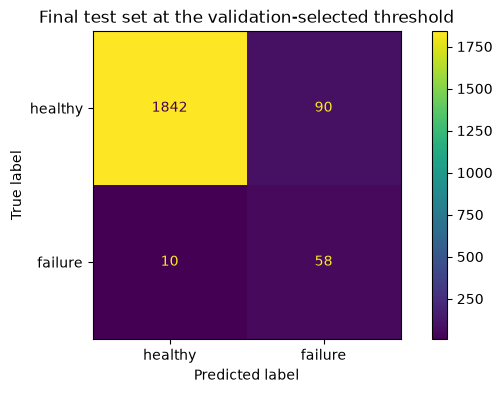

In [9]:
test_probability = alarm_model.predict_proba(X_test)[:, 1]
test_alarm = (test_probability >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, test_alarm, labels=[0, 1]).ravel()
test_cost = fn * C_MISS + fp * C_FALSE_ALARM
test_metrics = metric_row(y_test, test_alarm, test_probability)

default_alarm = (test_probability >= 0.50).astype(int)
_, default_fp, default_fn, _ = confusion_matrix(y_test, default_alarm, labels=[0, 1]).ravel()
default_cost = default_fn * C_MISS + default_fp * C_FALSE_ALARM

display(pd.Series(test_metrics, name="final test").round(3))
print(f"Selected threshold: {best_threshold:.2f}")
print(f"Missed failures: {fn} | False alarms: {fp}")
print(f"Test cost: £{test_cost:,.0f}")
print(f"Default-0.50 test cost: £{default_cost:,.0f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, test_alarm, display_labels=["healthy", "failure"]
)
plt.title("Final test set at the validation-selected threshold")
plt.show()

assert test_alarm.shape == y_test.shape

### Example recommendation

I recommend the random-forest alarm using the threshold selected from validation cost, typically around 0.05–0.10. The final test should report precision and recall alongside the actual numbers of missed failures and unnecessary inspections. The lower threshold generally costs materially less than the default 0.5 policy because it accepts more inspections to prevent expensive missed failures. Accuracy is not an appropriate headline measure because an always-healthy policy already achieves more than 90% while detecting nothing. Before deployment, the policy must be validated on time-separated plant data, checked for probability calibration and drift, and reviewed against the actual inspection capacity and failure costs.


### Optional solution: Which failure modes can the sensors predict?

In [ ]:
failure_audit = pm.loc[X_test.index, FAILURE_MODES].copy()
failure_audit["alarm"] = test_alarm

audit_rows = []
for mode in FAILURE_MODES:
    mode_rows = failure_audit[mode].eq(1)
    total = int(mode_rows.sum())
    caught = int(failure_audit.loc[mode_rows, "alarm"].sum())
    audit_rows.append({"mode": mode, "caught": caught, "total": total})

display(pd.DataFrame(audit_rows).set_index("mode"))

HDF, PWF and OSF are generated from observable physical rules and should be detected most reliably. TWF is partly random inside a wear-out region, while RNF is a random background failure; neither can be recovered perfectly from the available sensors. A credible deployment claim must therefore be mode-specific and must not promise that every failure is predictable.

## Optional classification extension solutions

These comparisons use the existing training and validation partitions only.

### A. Gradient-boosted trees

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

boosted_classifier = GradientBoostingClassifier(
    n_estimators=150, learning_rate=0.05, max_depth=3, random_state=0
)
boosted_classifier.fit(X_train, y_train)
boosted_prediction = boosted_classifier.predict(X_val)
boosted_probability = boosted_classifier.predict_proba(X_val)[:, 1]
boosted_metrics = metric_row(y_val, boosted_prediction, boosted_probability)
display(pd.Series(boosted_metrics, name="gradient boosting").round(3))

Boosting and random forests both combine trees, but a forest grows trees largely independently and averages them, while boosting grows learners sequentially to correct residual errors. On tabular data both are strong; validation performance, calibration, runtime and interpretability should determine the choice.

### B. kNN, SVM and naïve Bayes

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import GaussianNB

optional_classifiers = {
    "kNN (k=11)": make_pipeline(StandardScaler(), KNeighborsClassifier(11)),
    "RBF SVM": make_pipeline(
        StandardScaler(),
        CalibratedClassifierCV(
            SVC(kernel="rbf", class_weight="balanced"),
            method="sigmoid", cv=3,
        ),
    ),
    "Gaussian naïve Bayes": GaussianNB(),
}

optional_rows = []
for name, model in optional_classifiers.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_val)
    probability = model.predict_proba(X_val)[:, 1]
    optional_rows.append({"model": name, **metric_row(y_val, prediction, probability)})

optional_results = pd.DataFrame(optional_rows).set_index("model")
display(optional_results.round(3))

kNN and the RBF SVM depend on distances and therefore require scaling. Gaussian naïve Bayes is extremely fast but assumes features are conditionally independent within each class—an implausible assumption here because temperature variables are coupled and torque and speed are deliberately correlated. The exercise is intended to expose model assumptions, not create another leaderboard.